In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#1. Generate a synthetic non-stationary signal (500 seconds)
t = np.linspace(0, 500, 5000)  # 10Hz sampling rate
clean_signal = np.sin(2 * np.pi * 0.5 * t)  # A base 0.5Hz sine wave

# Simulate light source decay (non-stationarity)
offset_drift = 0.02 * t  # Additive noise (drifting up)
amplitude_scale = 1 + 0.5 * np.exp(-t / 200)  # Multiplicative noise (decaying amplitude)

raw_signal = (clean_signal * amplitude_scale) + offset_drift + np.random.normal(0, 0.1, len(t))

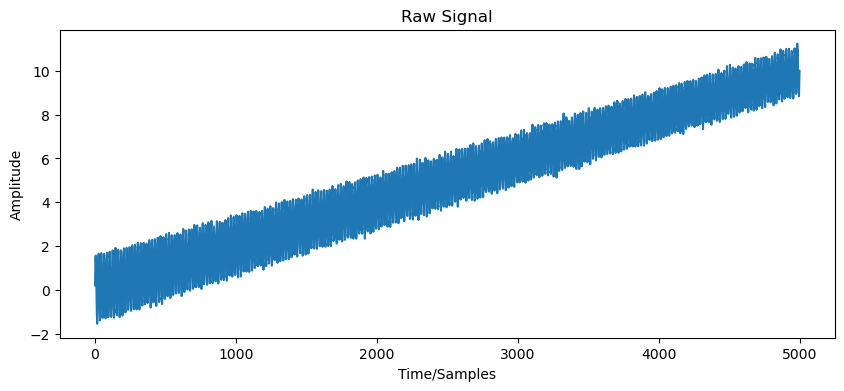

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(raw_signal)
plt.title('Raw Signal')
plt.xlabel('Time/Samples')
plt.ylabel('Amplitude')
plt.show()


In [7]:
# 2. Moving Window Normalization Function
def moving_window_norm(data, window_size_samples, sampling_rate):
    normalized = np.zeros_like(data)
    half_win = window_size_samples // 2
    
    for i in range(len(data)):
        # Define the 2-4 second window around the current point
        start = max(0, i - half_win)
        end = min(len(data), i + half_win)
        window_data = data[start:end]
        
        # Calculate local stats (Mean = Offset, Std = Amplitude)
        mu = np.mean(window_data)
        sigma = np.std(window_data)
        
        # Apply the formula: (X - mean) / std
        normalized[i] = (data[i] - mu) / (sigma if sigma != 0 else 1)

    # 2. Visualization phase (two panels)
    t = np.arange(len(data)) / sampling_rate
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Panel 1: Original non-stationary signal
    ax1.plot(t, data, color='tab:red', linewidth=1)
    ax1.set_title("Original Signal (Non-Stationary)")
    ax1.set_ylabel("Amplitude")
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Panel 2: Normalized stationary signal
    ax2.plot(t, normalized, color='tab:blue', linewidth=1)
    ax2.set_title(f"Normalized Signal (Moving Window: {window_size_samples/sampling_rate}s)")
    ax2.set_ylabel("Z-Score")
    ax2.set_xlabel("Time (seconds)")
    ax2.grid(True, linestyle='--', alpha=0.7)
            
    return normalized

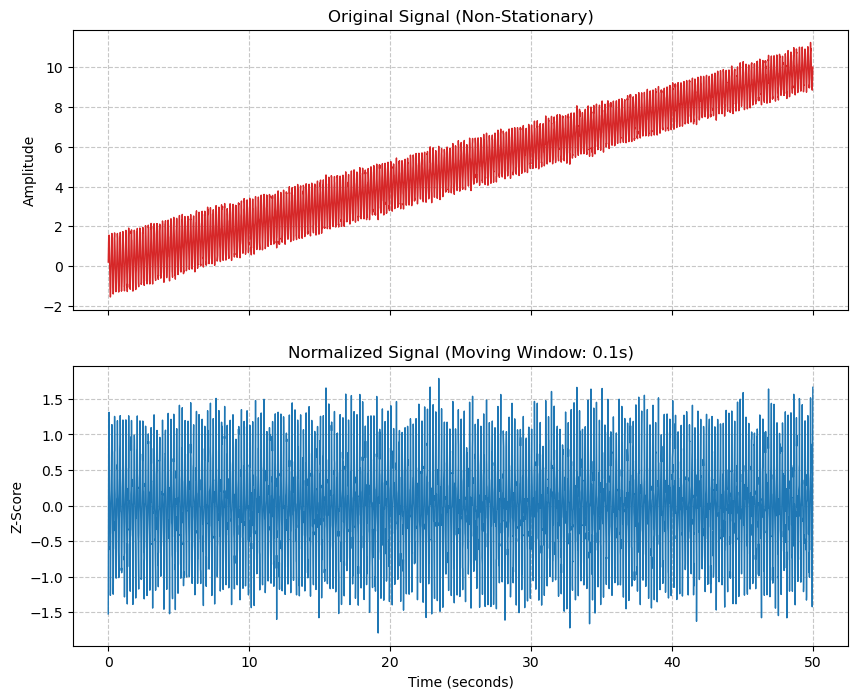

In [15]:
normal_signal = moving_window_norm(raw_signal, 10, 100)

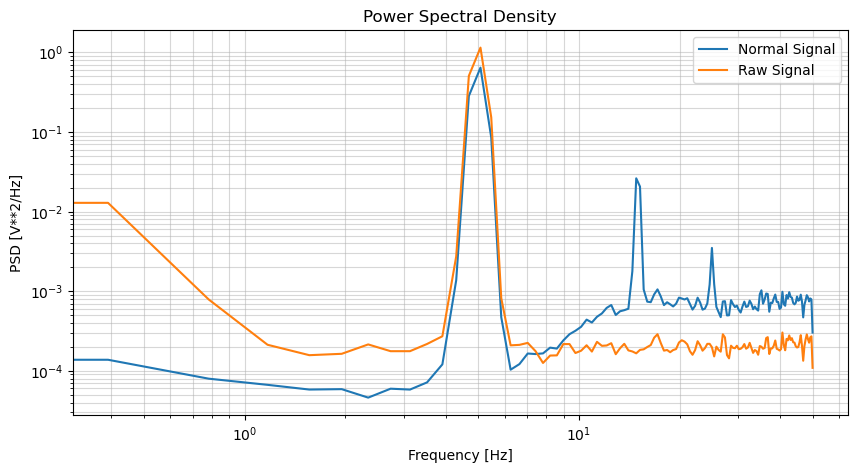

In [16]:
import matplotlib.pyplot as plt
from scipy.signal import welch

# Assuming 'signal' and 'fs' (sampling frequency) are defined
frequencies_normal, psd_normal = welch(normal_signal, 100)
frequencies, psd = welch(raw_signal, 100)

plt.figure(figsize=(10, 5))
plt.loglog(frequencies_normal, psd_normal)
plt.loglog(frequencies, psd)
plt.title('Power Spectral Density')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(['Normal Signal', 'Raw Signal'])
plt.show()
